In [1]:
# %pip install cmake dlib
# %pip install dlib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np
from PIL import Image
import dlib

In [16]:
def shape_to_list(shape):
	coords = []
	for i in range(0, 68):
		coords.append((shape.part(i).x, shape.part(i).y))
	return coords

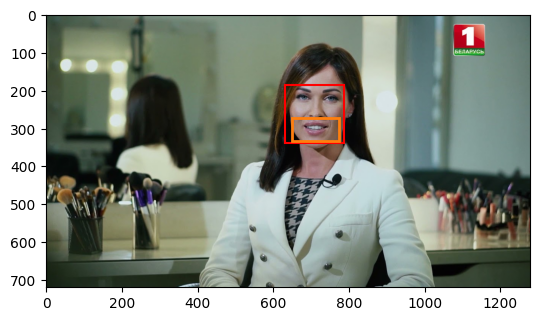

In [20]:
img = plt.imread('img/test_img.jpg')

# Face detector and landmark detector
face_detector = dlib.get_frontal_face_detector()   
landmark_detector = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")	# Landmark detector path


face_rects = face_detector(img,1)          # Detect face
rect = face_rects[0]                                    # Proper number of face
landmark = landmark_detector(img, rect)    # Detect face landmarks

landmark = shape_to_list(landmark)

scale = 0.8
fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(5/scale,3/scale))
ax.imshow(img,cmap='gray')
height = rect.bottom() - rect.top()
width  = rect.right()-rect.left()
ax.add_patch(plt.Rectangle((rect.left(), rect.top()), width, height, ls="-", ec="r", fc="none", lw=1.5))

LIP_MARGIN = 0.45                # Marginal rate for lip-only image.
lip_landmark = landmark[48:68]                                          # Landmark corresponding to lip
lip_x = sorted(lip_landmark, key = lambda pointx: pointx[0])            # Lip landmark sorted for determining lip region
lip_y = sorted(lip_landmark, key = lambda pointy: pointy[1])
x_add = int((-lip_x[0][0]+lip_x[-1][0])*LIP_MARGIN)                     # Determine Margins for lip-only image
y_add = int((-lip_y[0][1]+lip_y[-1][1])*LIP_MARGIN)
crop_pos = (lip_x[0][0]-x_add, lip_x[-1][0]+x_add, lip_y[0][1]-y_add, lip_y[-1][1]+y_add)

ax.add_patch(plt.Rectangle((lip_x[0][0]-x_add, lip_y[0][1]-y_add), lip_x[-1][0]-lip_x[0][0] + 2*x_add, lip_y[-1][1] - lip_y[0][1] + 2*y_add, ls="-", ec="C1", fc="none", lw=2.0))

# plt.tight_layout()
# image_name = '../Docs/sntk-62/Figures/face_lip_detection.jpg'
# fig.savefig(image_name, format='jpg', dpi=110, bbox_inches='tight', pad_inches = 0)

In [17]:
print('top    = ', rect.top())
print('bottom = ', rect.bottom())
print('left   = ', rect.left())
print('right  = ', rect.right())

top    =  184
bottom =  339
left   =  631
right  =  786
